### Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
predict_conversion_df = pd.read_csv('predict_conversion_in_digital_marketing.csv')

google_ads_df = pd.read_csv('GoogleAds_DataAnalytics_Sales_Uncleaned.csv')

marketing_and_product_df = pd.read_csv('marketing_and_product_performance.csv')


In [3]:
print('The info of Predict Conversion DF:', predict_conversion_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [207]:
print('The info of Google Ads DF:', google_ads_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   object 
 1   Campaign_Name    2600 non-null   object 
 2   Clicks           2488 non-null   float64
 3   Impressions      2546 non-null   float64
 4   Cost             2503 non-null   object 
 5   Leads            2552 non-null   float64
 6   Conversions      2526 non-null   float64
 7   Conversion Rate  1974 non-null   float64
 8   Sale_Amount      2461 non-null   object 
 9   Ad_Date          2600 non-null   object 
 10  Location         2600 non-null   object 
 11  Device           2600 non-null   object 
 12  Keyword          2600 non-null   object 
dtypes: float64(5), object(8)
memory usage: 264.2+ KB
The info of Google Ads DF: None


In [208]:
print('The info of Marketing and Product DF:', marketing_and_product_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Campaign_ID                        10000 non-null  object 
 1   Product_ID                         10000 non-null  object 
 2   Budget                             10000 non-null  float64
 3   Clicks                             10000 non-null  int64  
 4   Conversions                        10000 non-null  int64  
 5   Revenue_Generated                  10000 non-null  float64
 6   ROI                                10000 non-null  float64
 7   Customer_ID                        10000 non-null  object 
 8   Subscription_Tier                  10000 non-null  object 
 9   Subscription_Length                10000 non-null  int64  
 10  Flash_Sale_ID                      10000 non-null  object 
 11  Discount_Level                     10000 non-null  int6

Mean Imputation for Null Values of Columns in Google Ads DF

In [209]:
print("\nNull values count per column:")
print(google_ads_df.isnull().sum())




Null values count per column:
Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions         74
Conversion Rate    626
Sale_Amount        139
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64


In [210]:
cols_to_fix = ['Cost', 'Sale_Amount']
for col in cols_to_fix:
    if google_ads_df[col].dtype == 'object' or google_ads_df[col].dtype.name == 'string':
        google_ads_df[col] = google_ads_df[col].astype(str).str.replace(r'[$,]', '', regex=True)
    
   
    google_ads_df[col] = pd.to_numeric(google_ads_df[col], errors='coerce').round().astype('Int64')

google_ads_df[cols_to_fix].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Cost         2503 non-null   Int64
 1   Sale_Amount  2461 non-null   Int64
dtypes: Int64(2)
memory usage: 45.8 KB


C:\Users\santo\AppData\Local\Temp\ipykernel_4920\1725468743.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  google_ads_df[col] = google_ads_df[col].astype(str).str.replace(r'[$,]', '', regex=True)
C:\Users\santo\AppData\Local\Temp\ipyker

In [211]:
google_ads_df['Ad_Date'] = pd.to_datetime(google_ads_df['Ad_Date'], errors='coerce')
google_ads_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Ad_ID            2600 non-null   object        
 1   Campaign_Name    2600 non-null   object        
 2   Clicks           2488 non-null   float64       
 3   Impressions      2546 non-null   float64       
 4   Cost             2503 non-null   Int64         
 5   Leads            2552 non-null   float64       
 6   Conversions      2526 non-null   float64       
 7   Conversion Rate  1974 non-null   float64       
 8   Sale_Amount      2461 non-null   Int64         
 9   Ad_Date          893 non-null    datetime64[ns]
 10  Location         2600 non-null   object        
 11  Device           2600 non-null   object        
 12  Keyword          2600 non-null   object        
dtypes: Int64(2), datetime64[ns](1), float64(5), object(5)
memory usage: 269.3+ KB


C:\Users\santo\AppData\Local\Temp\ipykernel_4920\4271814330.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  google_ads_df['Ad_Date'] = pd.to_datetime(google_ads_df['Ad_Date'], errors='coerce')


In [212]:
numeric_cols = google_ads_df.select_dtypes(include=['number']).columns

google_ads_df[numeric_cols] = google_ads_df[numeric_cols].fillna(google_ads_df[numeric_cols].mean().round())

print("Null values count per column after imputation:")
print(google_ads_df.isnull().sum())

Null values count per column after imputation:
Ad_ID                 0
Campaign_Name         0
Clicks                0
Impressions           0
Cost                  0
Leads                 0
Conversions           0
Conversion Rate       0
Sale_Amount           0
Ad_Date            1707
Location              0
Device                0
Keyword               0
dtype: int64


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\pandas\core\generic.py:7406: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result[k] = res_k
C:\Users\santo\AppData\Local\Temp\ipykernel_4920\2420418613.py:3: FutureWa

Checking Datasets for Duplicates

In [213]:
print(f"Number of duplicate rows: {predict_conversion_df.duplicated().sum()}")

if predict_conversion_df.duplicated().sum() > 0:
    print("\nDuplicate Rows:")
    print(predict_conversion_df[predict_conversion_df.duplicated()])

Number of duplicate rows: 0


In [214]:
print(f"Number of duplicate rows in Google Ads DF: {google_ads_df.duplicated().sum()}")

if google_ads_df.duplicated().sum() > 0:
    print("\nDuplicate Rows in Google Ads DF:")
    print(google_ads_df[google_ads_df.duplicated()])

Number of duplicate rows in Google Ads DF: 0


In [215]:
print(f"Number of duplicate rows in Marketing and Product DF: {marketing_and_product_df.duplicated().sum()}")

if marketing_and_product_df.duplicated().sum() > 0:
    print("\nDuplicate Rows in Marketing and Product DF:")
    print(marketing_and_product_df[marketing_and_product_df.duplicated()])

Number of duplicate rows in Marketing and Product DF: 0


Removing Missing Data and NaNs

In [216]:
print("Null values count per column in Predict Conversion DF:")
print(predict_conversion_df.isnull().sum())

if predict_conversion_df.isnull().any().any():
    print("\nRows with missing values:")
    display(predict_conversion_df[predict_conversion_df.isnull().any(axis=1)])
else:
    print("\nNo missing values found in Predict Conversion DF.")

Null values count per column in Predict Conversion DF:
CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

No missing values found in Predict Conversion DF.


In [217]:
print("Null values count per column in Google Ads DF:")
print(google_ads_df.isnull().sum())

if google_ads_df.isnull().any().any():
    print("\nRows with missing values:")
    display(google_ads_df[google_ads_df.isnull().any(axis=1)])
else:
    print("\nNo missing values found in Google Ads DF.")

Null values count per column in Google Ads DF:
Ad_ID                 0
Campaign_Name         0
Clicks                0
Impressions           0
Cost                  0
Leads                 0
Conversions           0
Conversion Rate       0
Sale_Amount           0
Ad_Date            1707
Location              0
Device                0
Keyword               0
dtype: int64

Rows with missing values:


,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
1,A1001,DataAnalyticsCourse,173.0,5107.0,217,10.0,8.0,0.046,1679,NaT,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,204,26.0,9.0,0.000,1624,NaT,hyderabad,Desktop,data analitics online
5,A1005,DataAnalyticsCourse,195.0,3776.0,244,10.0,8.0,0.000,1315,NaT,hyderabad,MOBILE,data anaytics training
6,A1006,Data Analytics Corse,116.0,4480.0,238,17.0,5.0,0.043,1640,NaT,hyderabad,TABLET,data analytics course
7,A1007,Data Analytics Corse,184.0,5060.0,230,23.0,3.0,0.016,1509,NaT,Hyderbad,TABLET,analytics for data
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2593,A3593,Data Analytics Corse,189.0,5944.0,203,28.0,5.0,0.000,1360,NaT,HYDERABAD,MOBILE,data analytics course
2594,A3594,Data Anlytics Corse,99.0,4446.0,234,11.0,6.0,0.061,1189,NaT,hyderabad,Tablet,data anaytics training
2595,A3595,DataAnalyticsCourse,88.0,5344.0,242,17.0,9.0,0.054,1418,NaT,HYDERABAD,MOBILE,online data analytic
2596,A3596,DataAnalyticsCourse,154.0,3211.0,248,14.0,6.0,0.039,1950,NaT,hyderabad,TABLET,data analitics online


In [218]:
google_ads_df = google_ads_df.dropna(subset=['Ad_Date'])

categorical_cols = google_ads_df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    google_ads_df[col] = google_ads_df[col].fillna(google_ads_df[col].mode()[0])

print("Remaining null values in Google Ads DF:")
print(google_ads_df.isnull().sum())

Remaining null values in Google Ads DF:
Ad_ID              0
Campaign_Name      0
Clicks             0
Impressions        0
Cost               0
Leads              0
Conversions        0
Conversion Rate    0
Sale_Amount        0
Ad_Date            0
Location           0
Device             0
Keyword            0
dtype: int64


C:\Users\santo\AppData\Local\Temp\ipykernel_4920\727974106.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  google_ads_df[col] = google_ads_df[col].fillna(google_ads_df[col].mode()[0])


In [219]:
print("Null values count per column in Marketing and Product DF:")
print(marketing_and_product_df.isnull().sum())

if marketing_and_product_df.isnull().any().any():
    print("\nRows with missing values:")
    display(marketing_and_product_df[marketing_and_product_df.isnull().any(axis=1)])
else:
    print("\nNo missing values found in Marketing and Product DF.")

Null values count per column in Marketing and Product DF:
Campaign_ID                          0
Product_ID                           0
Budget                               0
Clicks                               0
Conversions                          0
Revenue_Generated                    0
ROI                                  0
Customer_ID                          0
Subscription_Tier                    0
Subscription_Length                  0
Flash_Sale_ID                        0
Discount_Level                       0
Units_Sold                           0
Bundle_ID                            0
Bundle_Price                         0
Customer_Satisfaction_Post_Refund    0
Common_Keywords                      0
dtype: int64

No missing values found in Marketing and Product DF.


One-Hot Encoding

In [220]:
print("Categorical variables in Predict Conversion DF:")
print(predict_conversion_df.select_dtypes(include=['object', 'category']).columns.tolist())

print("\nCategorical variables in Google Ads DF:")
print(google_ads_df.select_dtypes(include=['object', 'category']).columns.tolist())

print("\nCategorical variables in Marketing and Product DF:")
print(marketing_and_product_df.select_dtypes(include=['object', 'category']).columns.tolist())

Categorical variables in Predict Conversion DF:
['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform', 'AdvertisingTool']

Categorical variables in Google Ads DF:
['Ad_ID', 'Campaign_Name', 'Location', 'Device', 'Keyword']

Categorical variables in Marketing and Product DF:
['Campaign_ID', 'Product_ID', 'Customer_ID', 'Subscription_Tier', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords']


In [221]:
categorical_cols = predict_conversion_df.select_dtypes(include=['object', 'category']).columns

predict_conversion_df = pd.get_dummies(predict_conversion_df, columns=categorical_cols, drop_first=True, dtype=int)

predict_conversion_df.head()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,...,LoyaltyPoints,Conversion,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,8000,56,136912,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,...,688,1,0,0,0,0,1,0,0,0
1,8001,69,41760,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,...,3459,1,1,0,0,0,0,0,0,1
2,8002,46,88456,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,...,2337,1,0,1,0,0,0,0,0,0
3,8003,32,44085,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,...,2463,1,0,1,0,0,0,0,1,0
4,8004,60,83964,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,...,4345,1,0,1,0,0,0,0,1,0


In [222]:
google_ads_categorical_cols = google_ads_df.select_dtypes(include=['object', 'category']).columns

google_ads_df = pd.get_dummies(google_ads_df, columns=google_ads_categorical_cols, drop_first=True, dtype=int)

google_ads_df = google_ads_df.drop(columns=[col for col in google_ads_df.columns if 'Ad_ID_' in col])

google_ads_df.head()

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Campaign_Name_Data Analytics Corse,Campaign_Name_Data Anlytics Corse,...,Device_TABLET,Device_Tablet,Device_desktop,Device_mobile,Device_tablet,Keyword_data analitics online,Keyword_data analytics course,Keyword_data anaytics training,Keyword_learn data analytics,Keyword_online data analytic
0,104.0,4498.0,232,14.0,7.0,0.058,1892,2024-11-16,0,0,...,0,0,1,0,0,0,0,0,1,0
3,142.0,3185.0,238,17.0,6.0,0.000,1225,2024-11-26,0,0,...,0,0,0,0,1,0,0,1,0,0
4,156.0,3361.0,196,30.0,8.0,0.000,1091,2024-11-22,1,0,...,0,0,1,0,0,0,0,0,0,1
14,181.0,4311.0,185,11.0,9.0,0.050,1538,2024-11-04,0,0,...,0,0,0,0,0,0,0,1,0,0
15,102.0,5461.0,202,22.0,8.0,0.078,1755,2024-11-29,0,0,...,0,0,1,0,0,0,1,0,0,0


In [227]:
marketing_categorical_cols = marketing_and_product_df.select_dtypes(include=['object', 'category']).columns

marketing_categorical_cols = [col for col in marketing_categorical_cols if not col.startswith('Flash_Sale_ID_FLASH') and not 'ID' in col]

marketing_and_product_df = pd.get_dummies(marketing_and_product_df, columns=marketing_categorical_cols, drop_first=True, dtype=int)

marketing_and_product_df = marketing_and_product_df.drop(columns=[col for col in marketing_and_product_df.columns if 'ID' in col] or [col for col in marketing_and_product_df.columns if col.startswith('Flash_Sale_ID_FLASH')])

marketing_and_product_df.head()


,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund,Subscription_Tier_Premium,Subscription_Tier_Standard,Common_Keywords_Durable,Common_Keywords_Innovative,Common_Keywords_Stylish
0,41770.45,4946,73,15520.09,1.94,4,43,34,433.80,4,1,0,0,0,0
1,29900.93,570,510,30866.17,0.76,4,28,97,289.29,2,1,0,0,1,0
2,22367.45,3546,265,32585.62,1.41,9,51,160,462.87,4,0,0,0,0,0
3,29957.54,2573,781,95740.12,3.32,32,36,159,334.16,1,1,0,1,0,0
4,36277.19,818,79,81990.43,3.53,29,20,52,371.67,2,0,1,0,0,0


Checking for Class Imbalance

Class Imbalance Check (Conversion):
Conversion
1    7012
0     988
Name: count, dtype: int64


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-p

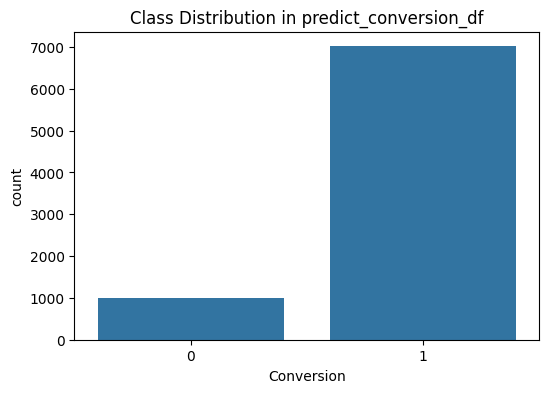

In [224]:
target_counts = predict_conversion_df['Conversion'].value_counts()
print("Class Imbalance Check (Conversion):")
print(target_counts)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Conversion', data=predict_conversion_df)
plt.title('Class Distribution in predict_conversion_df')
plt.show()

c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data


Distribution of 'Conversions' (counts):
Conversions
3.0     111
4.0     103
5.0     108
6.0     102
7.0     146
8.0     106
9.0     113
10.0    104
Name: count, dtype: int64


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\categorical.py:1292: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  agg_data["edge"] = agg_data[self.orient] - agg_data["width"] / 2
c:\Users\santo\OneDrive\Doc

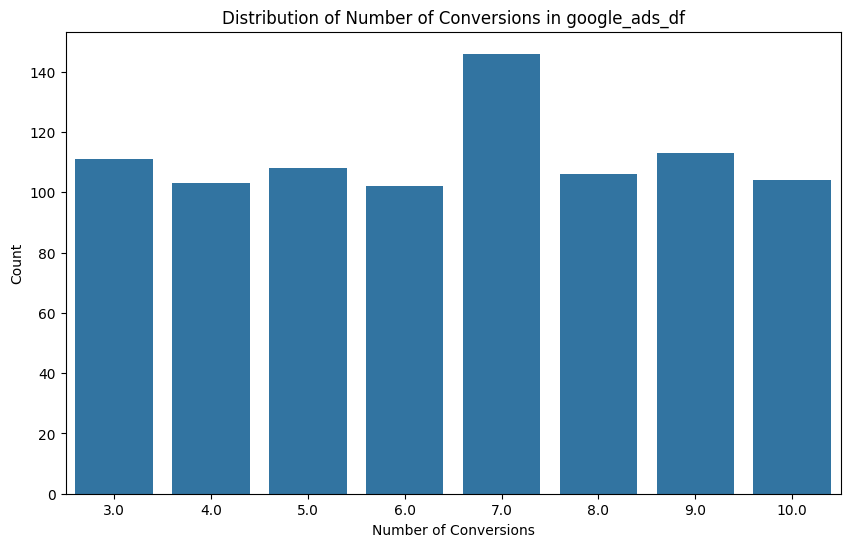

In [225]:
conversions_counts = google_ads_df['Conversions'].value_counts().sort_index()
print("Distribution of 'Conversions' (counts):")
print(conversions_counts)

plt.figure(figsize=(10, 6))
sns.countplot(x='Conversions', data=google_ads_df)
plt.title('Distribution of Number of Conversions in google_ads_df')
plt.xlabel('Number of Conversions')
plt.ylabel('Count')
plt.show()

Distribution of 'Conversions' (counts) in Marketing and Product DF:
Conversions
1       9
2      10
3      15
4      10
5      10
       ..
995    11
996     9
997     8
998    14
999    10
Name: count, Length: 999, dtype: int64


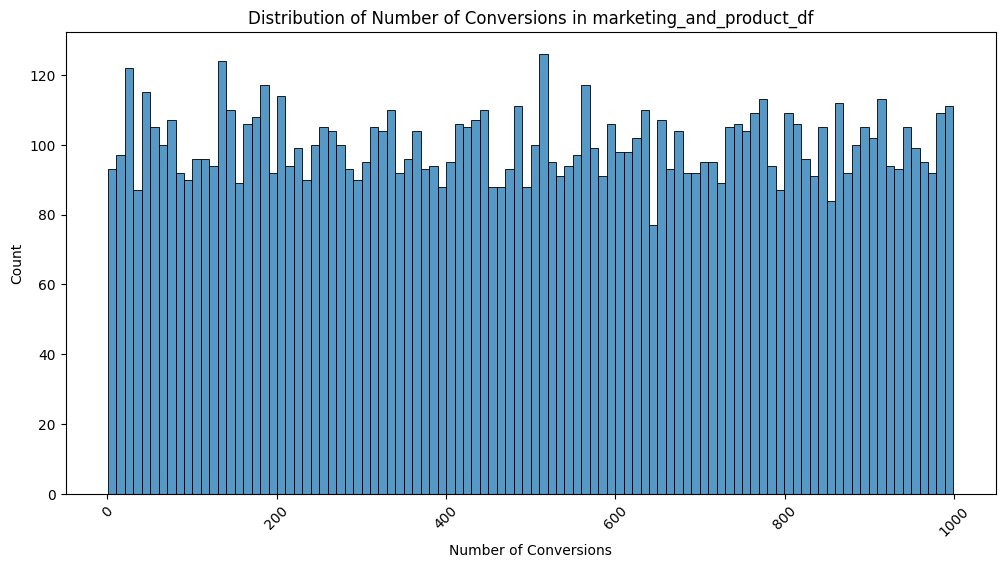

In [226]:
marketing_conversions_counts = marketing_and_product_df['Conversions'].value_counts().sort_index()

print("Distribution of 'Conversions' (counts) in Marketing and Product DF:")
print(marketing_conversions_counts)

plt.figure(figsize=(12, 6))
sns.histplot(x='Conversions', data=marketing_and_product_df, bins=100)
plt.title('Distribution of Number of Conversions in marketing_and_product_df')
plt.xlabel('Number of Conversions')
plt.ylabel('Count')
plt.xticks(rotation=45) 
plt.show()

### Univariate Analysis

variable separation

In [ ]:
numerical_features = predict_conversion_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = predict_conversion_df.select_dtypes(include=['object']).columns.tolist()

if 'CustomerID' in numerical_features:
    numerical_features.remove('CustomerID')

if 'Conversion' in numerical_features and predict_conversion_df['Conversion'].nunique() <= 2:
    if 'Conversion' in numerical_features:
        numerical_features.remove('Conversion')
    if 'Conversion' not in categorical_features:
        categorical_features.append('Conversion')

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

Numerical features: ['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']
Categorical features: ['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform', 'AdvertisingTool', 'Conversion']


In [ ]:

numeric_features_ads = google_ads_df.select_dtypes(include=['int64', 'float64', 'int32', 'Int64']).columns.tolist()
categorical_features_ads = google_ads_df.select_dtypes(include=['object', 'category']).columns.tolist()
datetime_features_ads = google_ads_df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

exclude_cols = ['Ad_ID', 'CustomerID']
numeric_features_ads = [col for col in numeric_features_ads if col not in exclude_cols and not col.startswith('Ad_ID')]
categorical_features_ads = [col for col in categorical_features_ads if col not in exclude_cols and not col.startswith('Ad_ID')]

print(f"Numerical features: {numeric_features_ads}")
print(f"Categorical features: {categorical_features_ads}")
print(f"Datetime features: {datetime_features_ads}")


Numerical features: ['Clicks', 'Impressions', 'Leads', 'Conversions', 'Conversion Rate']
Categorical features: ['Campaign_Name', 'Cost', 'Sale_Amount', 'Ad_Date', 'Location', 'Device', 'Keyword']
Datetime features: []


In [ ]:
numeric_features_mkt = marketing_and_product_df.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
categorical_features_mkt = marketing_and_product_df.select_dtypes(include=['object', 'category']).columns.tolist()
datetime_features_mkt = marketing_and_product_df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

exclude_patterns = ['ID', 'Date'] 
plot_numeric_mkt = [col for col in numeric_features_mkt if not any(x in col for x in exclude_patterns)]
plot_categorical_mkt = [col for col in categorical_features_mkt if not any(x in col for x in exclude_patterns)]

print(f"Numerical features to plot: {plot_numeric_mkt}")
print(f"Categorical features to plot: {plot_categorical_mkt}")
print(f"Datetime features: {datetime_features_mkt}")


Numerical features to plot: ['Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'ROI', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund']
Categorical features to plot: ['Subscription_Tier', 'Common_Keywords']
Datetime features: []


Visualization and Statistics


--- Numerical Features Summary Statistics ---


,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500
std,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162
min,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000
50%,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000
75%,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000
max,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000


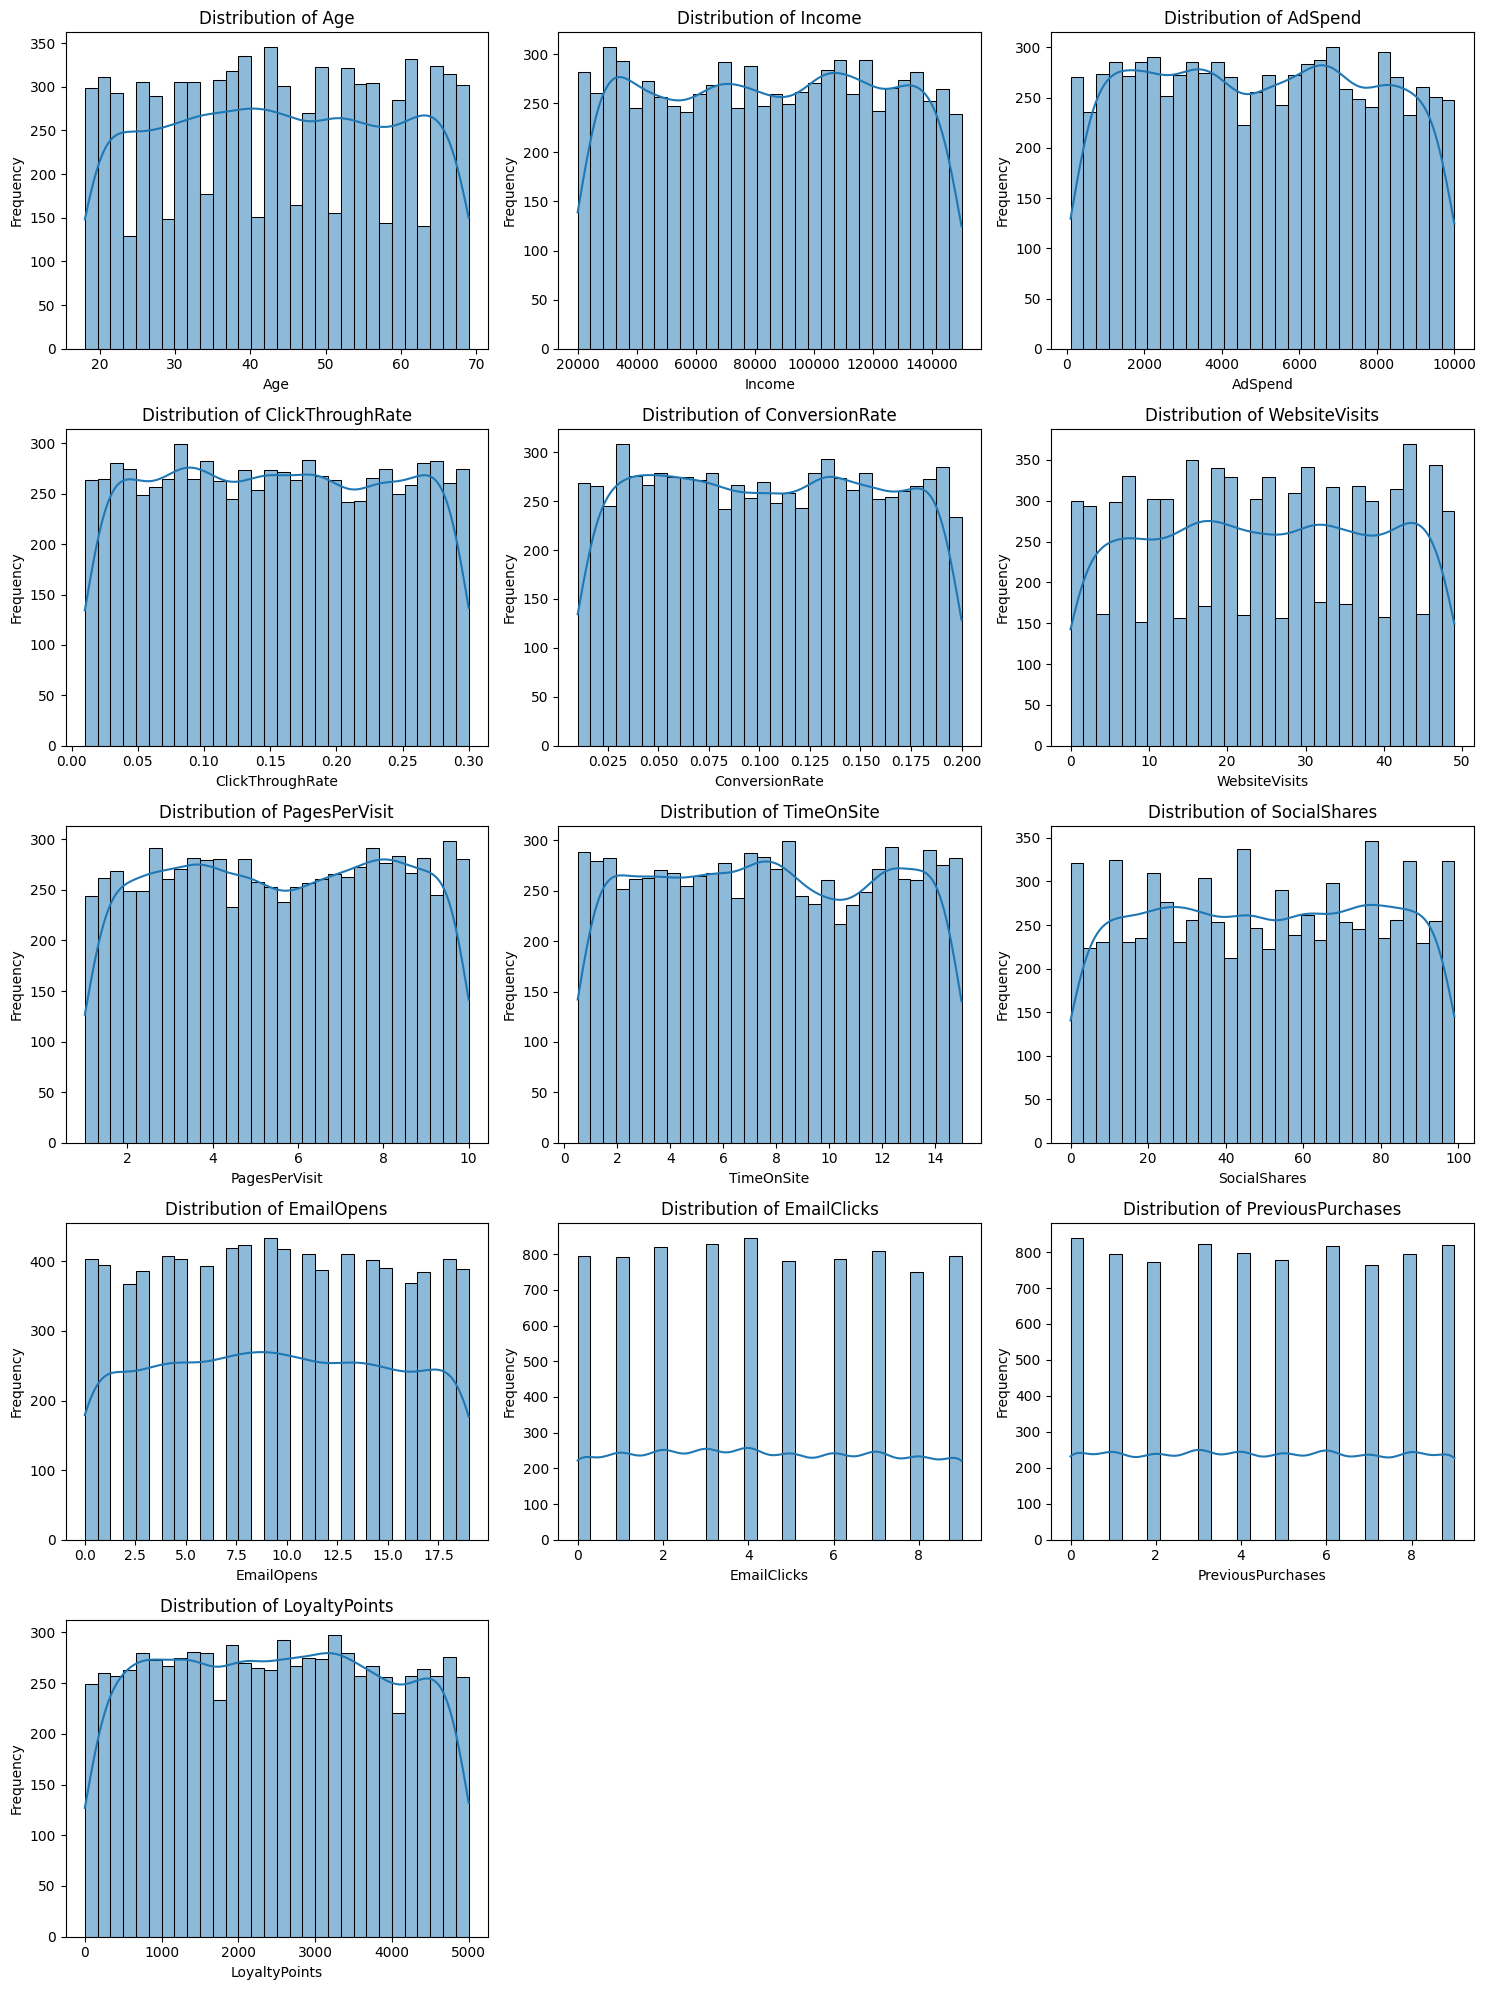


--- Categorical Features Value Counts ---

Gender:
Gender
Female    0.604875
Male      0.395125
Name: proportion, dtype: float64

CampaignChannel:
CampaignChannel
Referral        0.214875
PPC             0.206875
Email           0.194625
SEO             0.193750
Social Media    0.189875
Name: proportion, dtype: float64

CampaignType:
CampaignType
Conversion       0.259625
Awareness        0.248500
Consideration    0.248500
Retention        0.243375
Name: proportion, dtype: float64

AdvertisingPlatform:
AdvertisingPlatform
IsConfid    1.0
Name: proportion, dtype: float64

AdvertisingTool:
AdvertisingTool
ToolConfid    1.0
Name: proportion, dtype: float64

Conversion:
Conversion
1    0.8765
0    0.1235
Name: proportion, dtype: float64


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-p

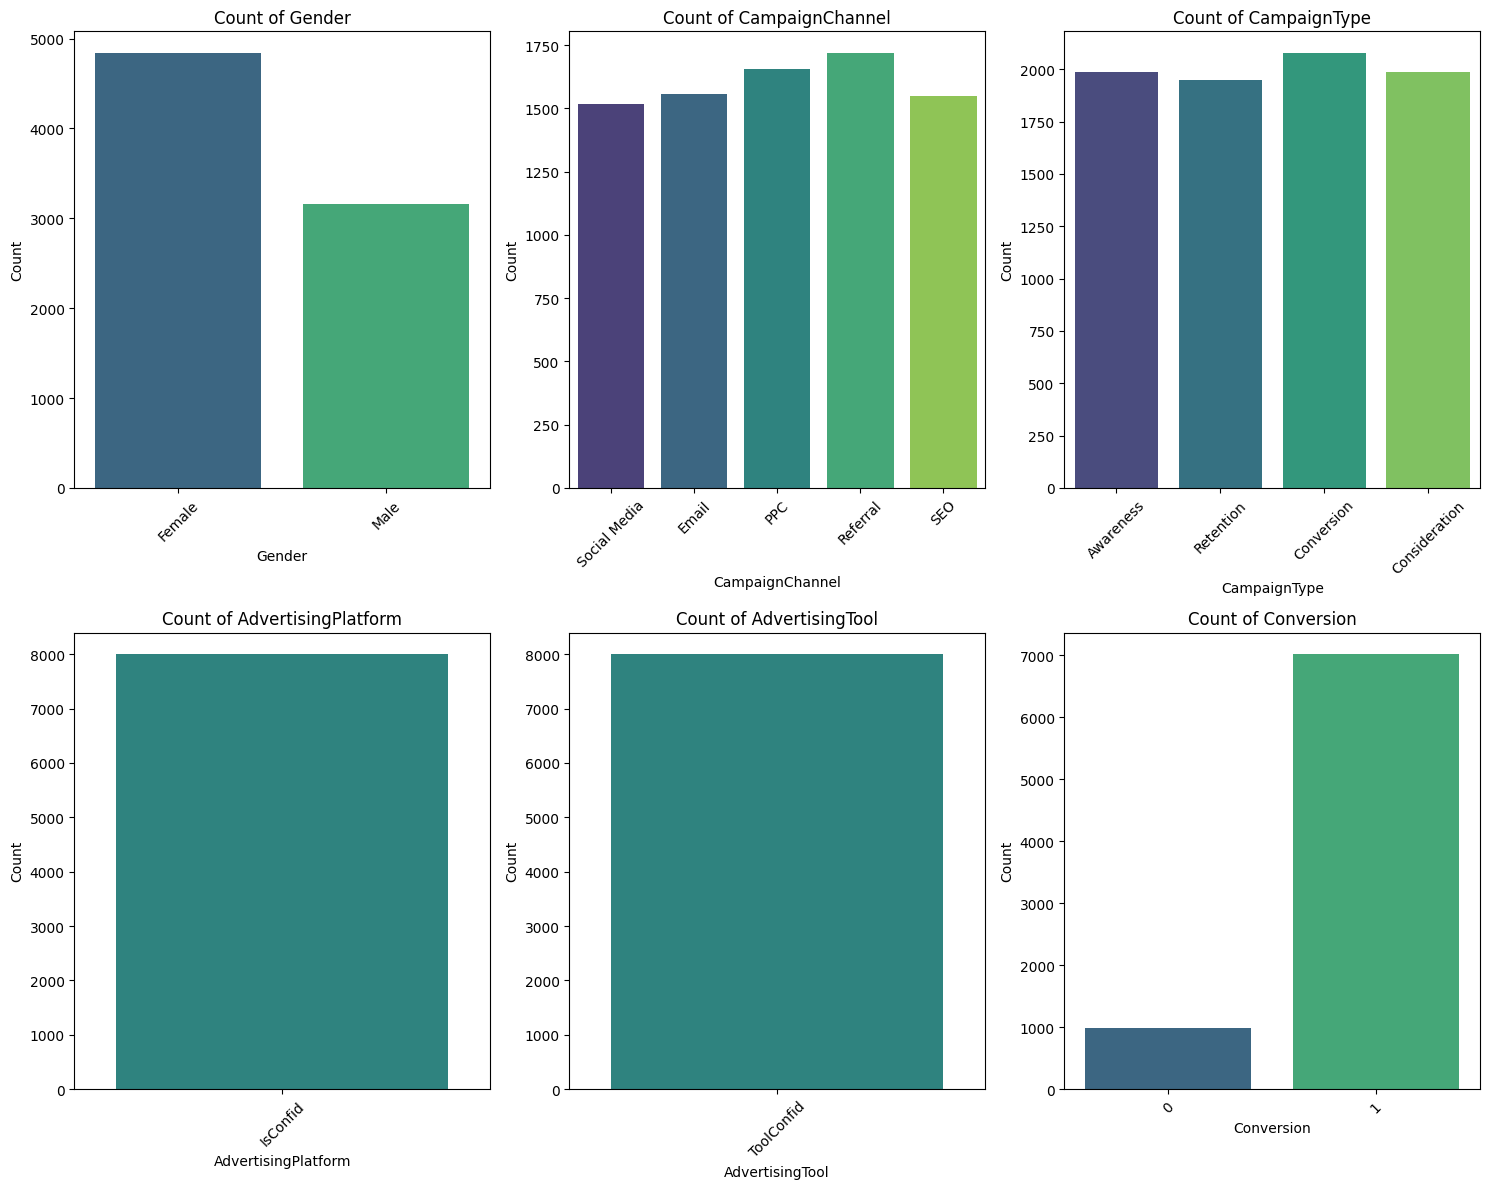

In [ ]:


print("\n--- Numerical Features Summary Statistics ---")
display(predict_conversion_df[numerical_features].describe())

plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_features):
    plt.subplot((len(numerical_features) + 2) // 3, 3, i + 1)
    sns.histplot(predict_conversion_df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n--- Categorical Features Value Counts ---")
for col in categorical_features:
    print(f"\n{col}:")
    print(predict_conversion_df[col].value_counts(normalize=True))

plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_features):
    plt.subplot((len(categorical_features) + 2) // 3, 3, i + 1)
    sns.countplot(x=col, data=predict_conversion_df, hue=col, palette='viridis', legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


--- Numerical Features Summary Statistics (Google Ads) ---


,Clicks,Impressions,Leads,Conversions,Conversion Rate
count,2488.000000,2546.000000,2552.000000,2526.000000,1974.000000
mean,138.956994,4523.280833,20.003918,6.519002,0.048979
std,34.619376,869.927913,6.032317,2.272573,0.019987
min,80.000000,3000.000000,10.000000,3.000000,0.015000
25%,110.000000,3764.000000,15.000000,5.000000,0.035000
50%,139.000000,4518.500000,20.000000,7.000000,0.046000
75%,169.000000,5279.500000,25.000000,9.000000,0.058000
max,199.000000,5999.000000,30.000000,10.000000,0.123000


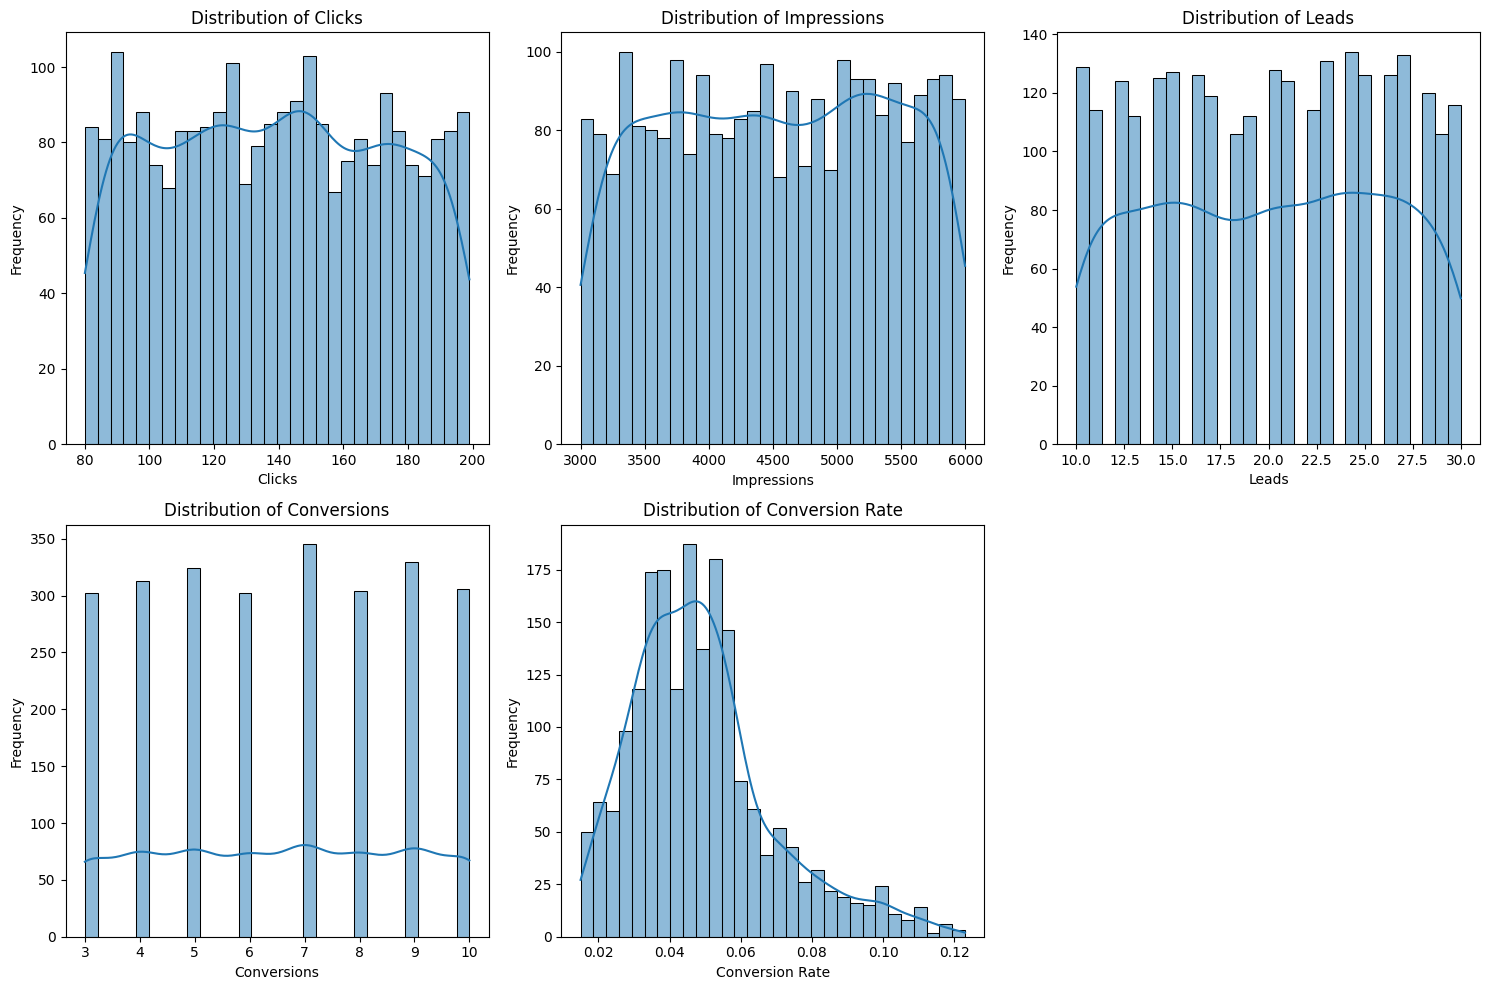


--- Categorical Features Value Counts (Google Ads) ---


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_18968\2935305792.py:29

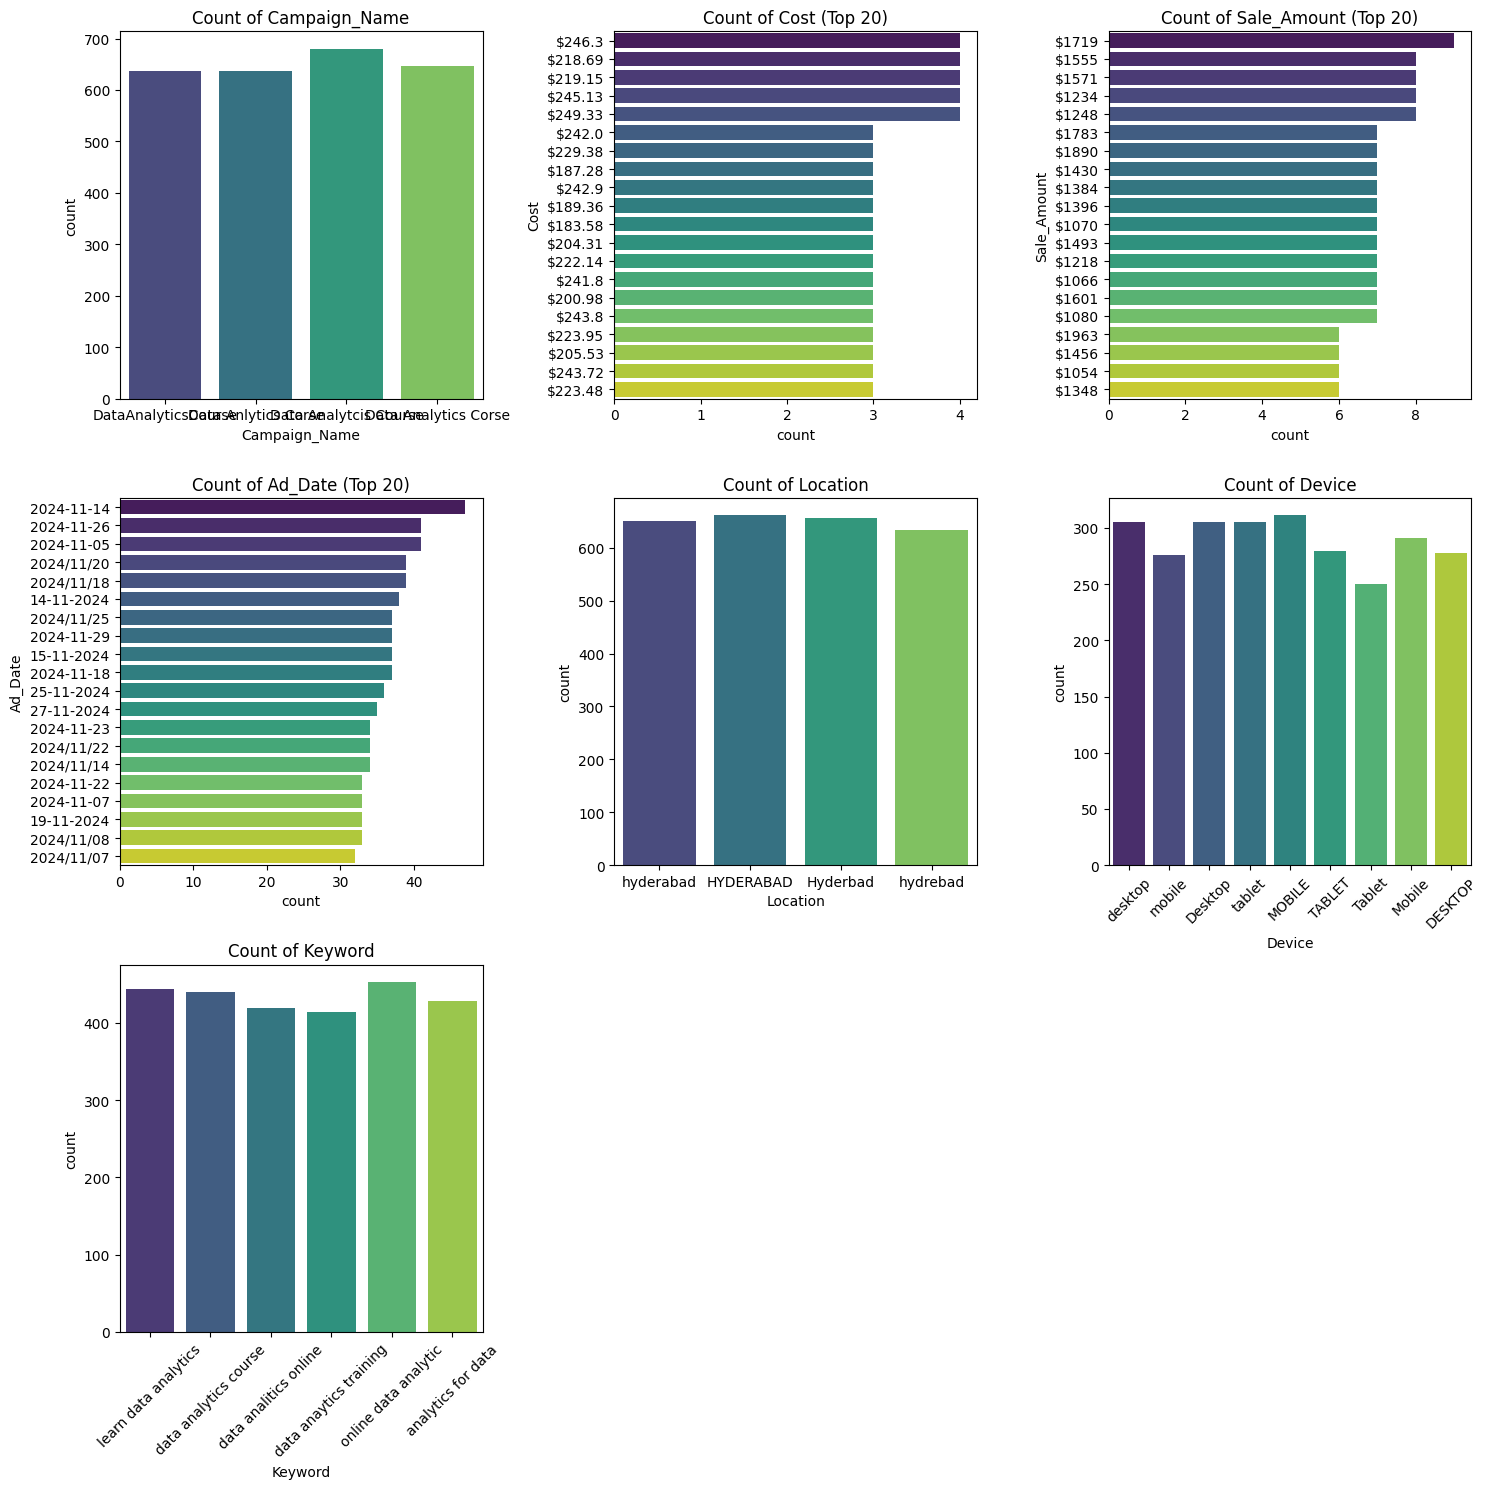

In [ ]:

if numeric_features_ads:
    print("\n--- Numerical Features Summary Statistics (Google Ads) ---")
    display(google_ads_df[numeric_features_ads].describe())

    plt.figure(figsize=(15, 5 * ((len(numeric_features_ads) + 2) // 3)))
    for i, col in enumerate(numeric_features_ads):
        plt.subplot((len(numeric_features_ads) + 2) // 3, 3, i + 1)
        sns.histplot(google_ads_df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

if categorical_features_ads:
    print("\n--- Categorical Features Value Counts (Google Ads) ---")
    plt.figure(figsize=(15, 5 * ((len(categorical_features_ads) + 2) // 3)))
    for i, col in enumerate(categorical_features_ads):
        plt.subplot((len(categorical_features_ads) + 2) // 3, 3, i + 1)
        if google_ads_df[col].nunique() > 20:
            top_20 = google_ads_df[col].value_counts().nlargest(20).index
            sns.countplot(y=col, data=google_ads_df[google_ads_df[col].isin(top_20)], order=top_20, palette='viridis', legend=False)
            plt.title(f'Count of {col} (Top 20)')
        else:
            sns.countplot(x=col, data=google_ads_df, palette='viridis', legend=False)
            plt.title(f'Count of {col}')
            if google_ads_df[col].nunique() > 5:
                plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

if datetime_features_ads:
    print("\n--- Datetime Features Analysis (Google Ads) ---")
    for col in datetime_features_ads:
        plt.figure(figsize=(15, 6))
        google_ads_df[col].hist(bins=50)
        plt.title(f'Distribution of {col}')
        plt.xlabel('Date')
        plt.ylabel('Frequency')
        plt.show()


--- Numerical Features Summary Statistics (Marketing & Product) ---


,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25263.607524,2481.903600,498.978700,50038.627579,2.756365,18.016500,39.421000,100.689600,275.198346,2.500900
std,14350.085927,1435.973623,289.479495,28545.702337,1.296901,10.149666,17.212925,57.074015,129.218710,1.113249
min,500.440000,10.000000,1.000000,1002.080000,0.500000,1.000000,10.000000,1.000000,50.010000,1.000000
25%,12789.190000,1225.750000,247.000000,25264.255000,1.630000,9.000000,24.000000,52.000000,165.717500,2.000000
50%,25030.170000,2451.000000,499.000000,49513.815000,2.750000,18.000000,39.000000,101.000000,272.555000,2.000000
75%,37921.725000,3723.000000,751.000000,74507.157500,3.890000,27.000000,54.000000,150.000000,387.322500,3.000000
max,49999.630000,4999.000000,999.000000,99999.470000,5.000000,35.000000,69.000000,199.000000,499.970000,4.000000


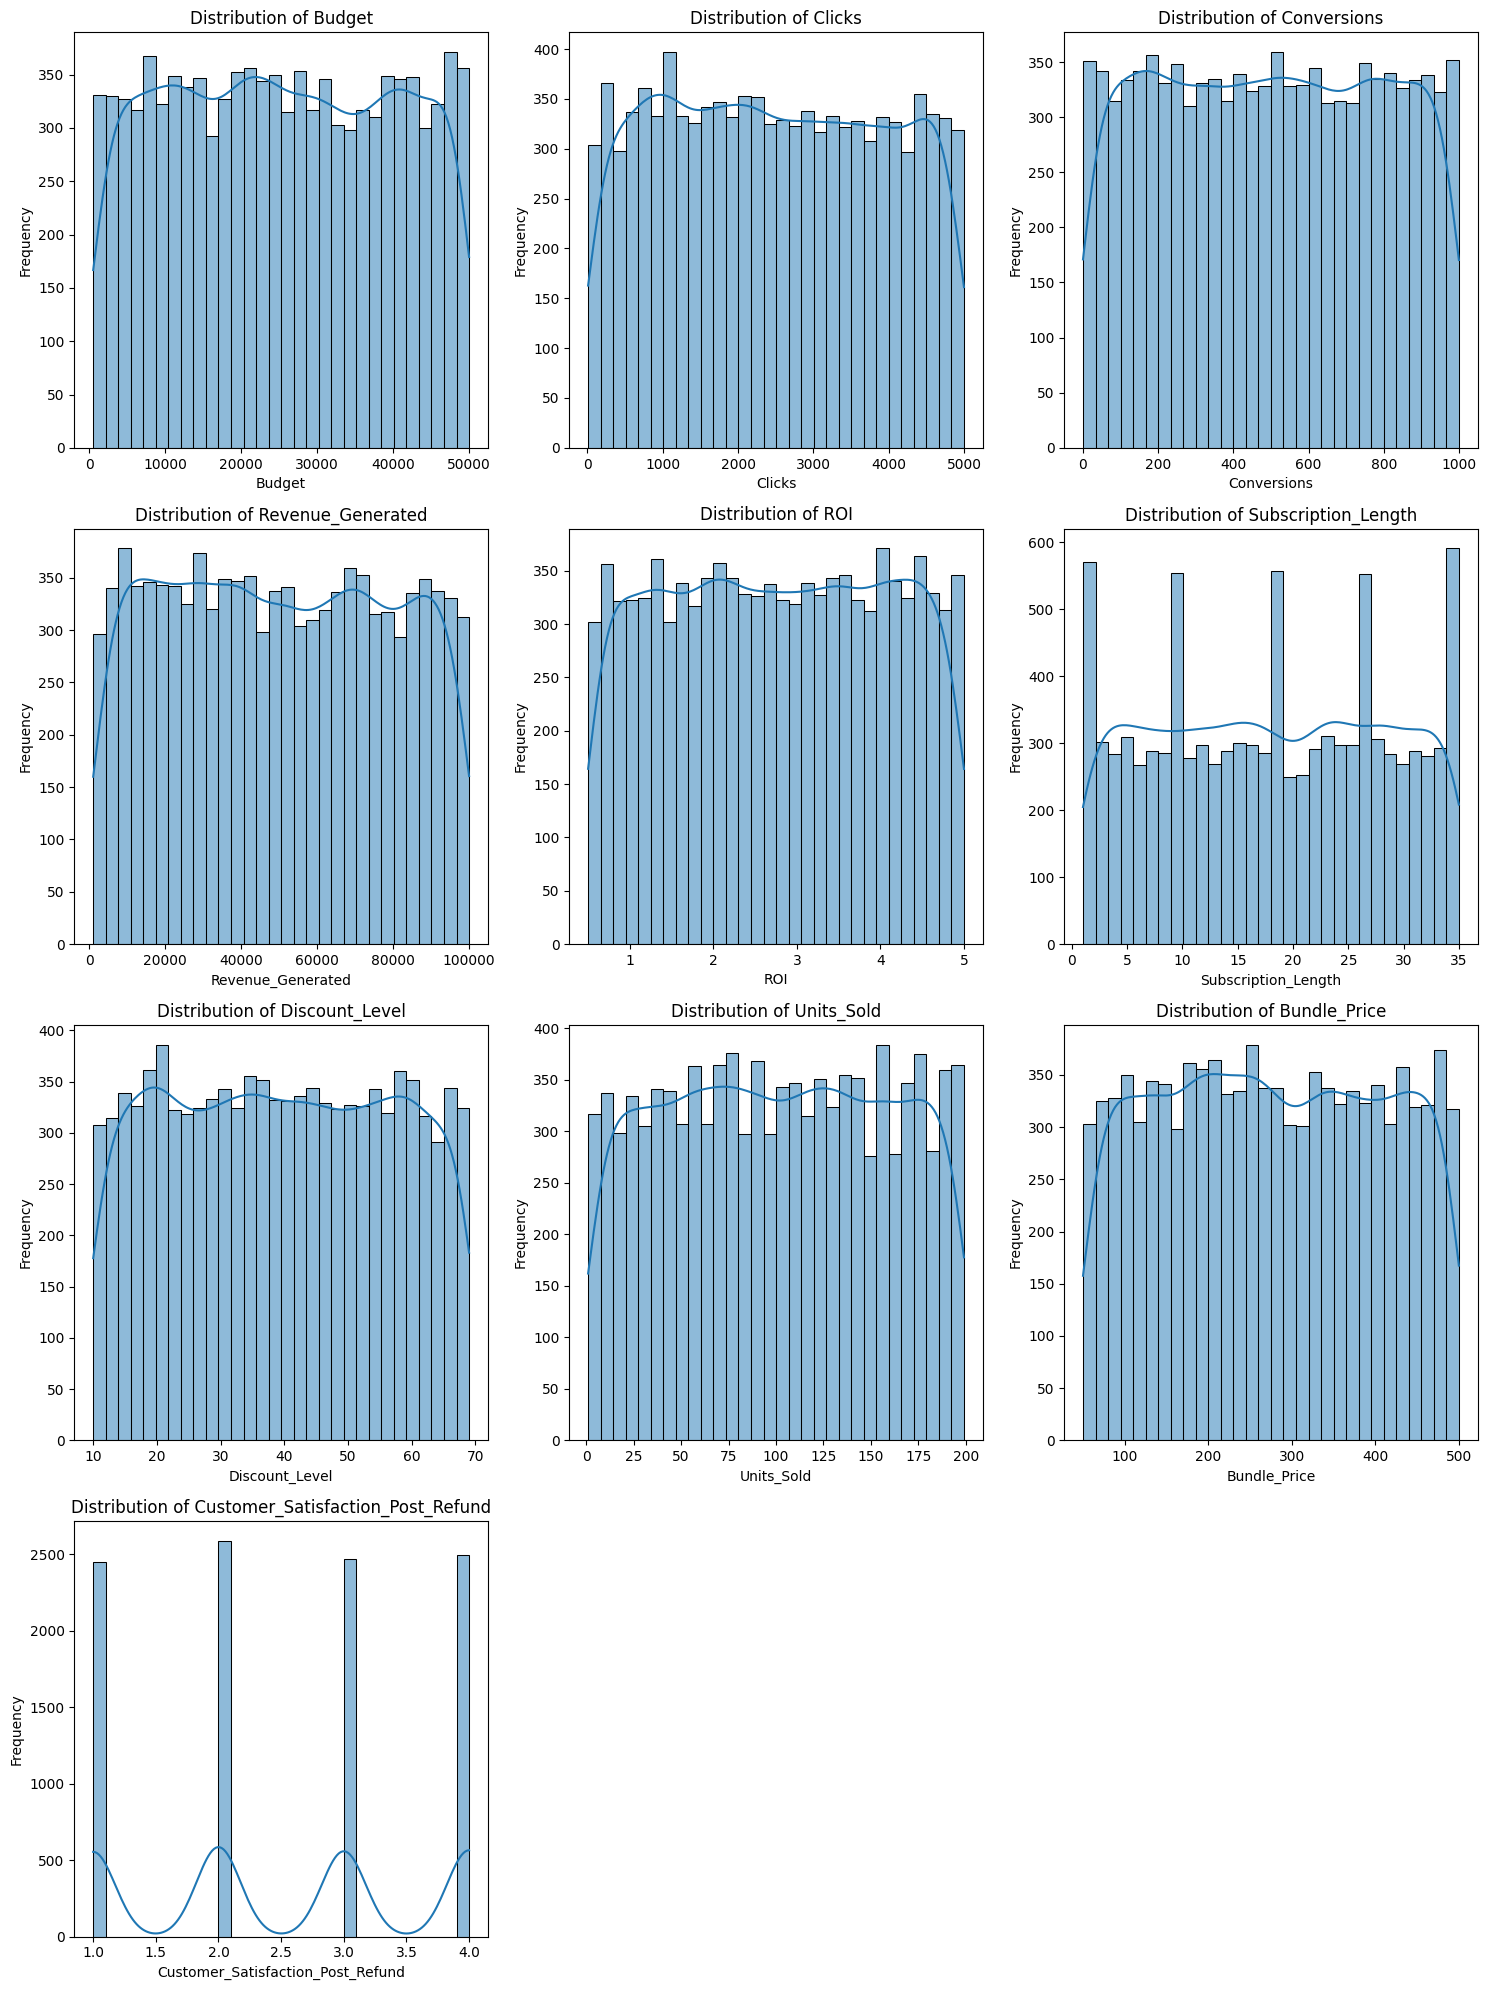


--- Categorical Features Value Counts (Marketing & Product) ---


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_18968\1336540261.py:29

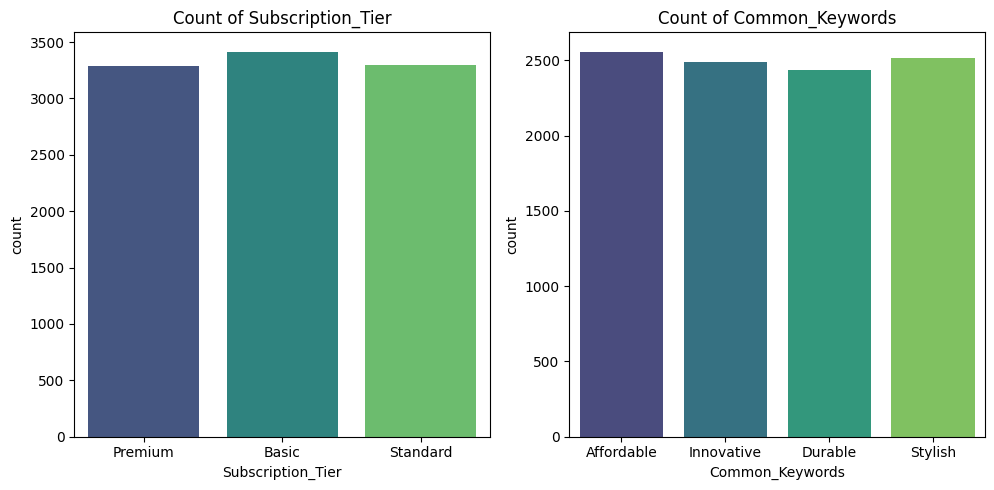

In [ ]:

if plot_numeric_mkt:
    print("\n--- Numerical Features Summary Statistics (Marketing & Product) ---")
    display(marketing_and_product_df[plot_numeric_mkt].describe())

    plt.figure(figsize=(15, 5 * ((len(plot_numeric_mkt) + 2) // 3)))
    for i, col in enumerate(plot_numeric_mkt):
        plt.subplot((len(plot_numeric_mkt) + 2) // 3, 3, i + 1)
        sns.histplot(marketing_and_product_df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

if plot_categorical_mkt:
    print("\n--- Categorical Features Value Counts (Marketing & Product) ---")
    plt.figure(figsize=(15, 5 * ((len(plot_categorical_mkt) + 2) // 3)))
    for i, col in enumerate(plot_categorical_mkt):
        plt.subplot((len(plot_categorical_mkt) + 2) // 3, 3, i + 1)
        
        if marketing_and_product_df[col].nunique() > 20:
            top_20 = marketing_and_product_df[col].value_counts().nlargest(20).index
            sns.countplot(y=col, data=marketing_and_product_df[marketing_and_product_df[col].isin(top_20)], order=top_20, palette='viridis', legend=False)
            plt.title(f'Count of {col} (Top 20)')
        else:
            sns.countplot(x=col, data=marketing_and_product_df, palette='viridis', legend=False)
            plt.title(f'Count of {col}')
            if marketing_and_product_df[col].nunique() > 5:
                plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


potential_date_cols = [col for col in marketing_and_product_df.columns if 'Date' in col]
if potential_date_cols:
     print(f"\nPotential Date columns identified by name: {potential_date_cols}")
